Saved plot to 'plots/train_attack_sequence_nodes_a_h.png'


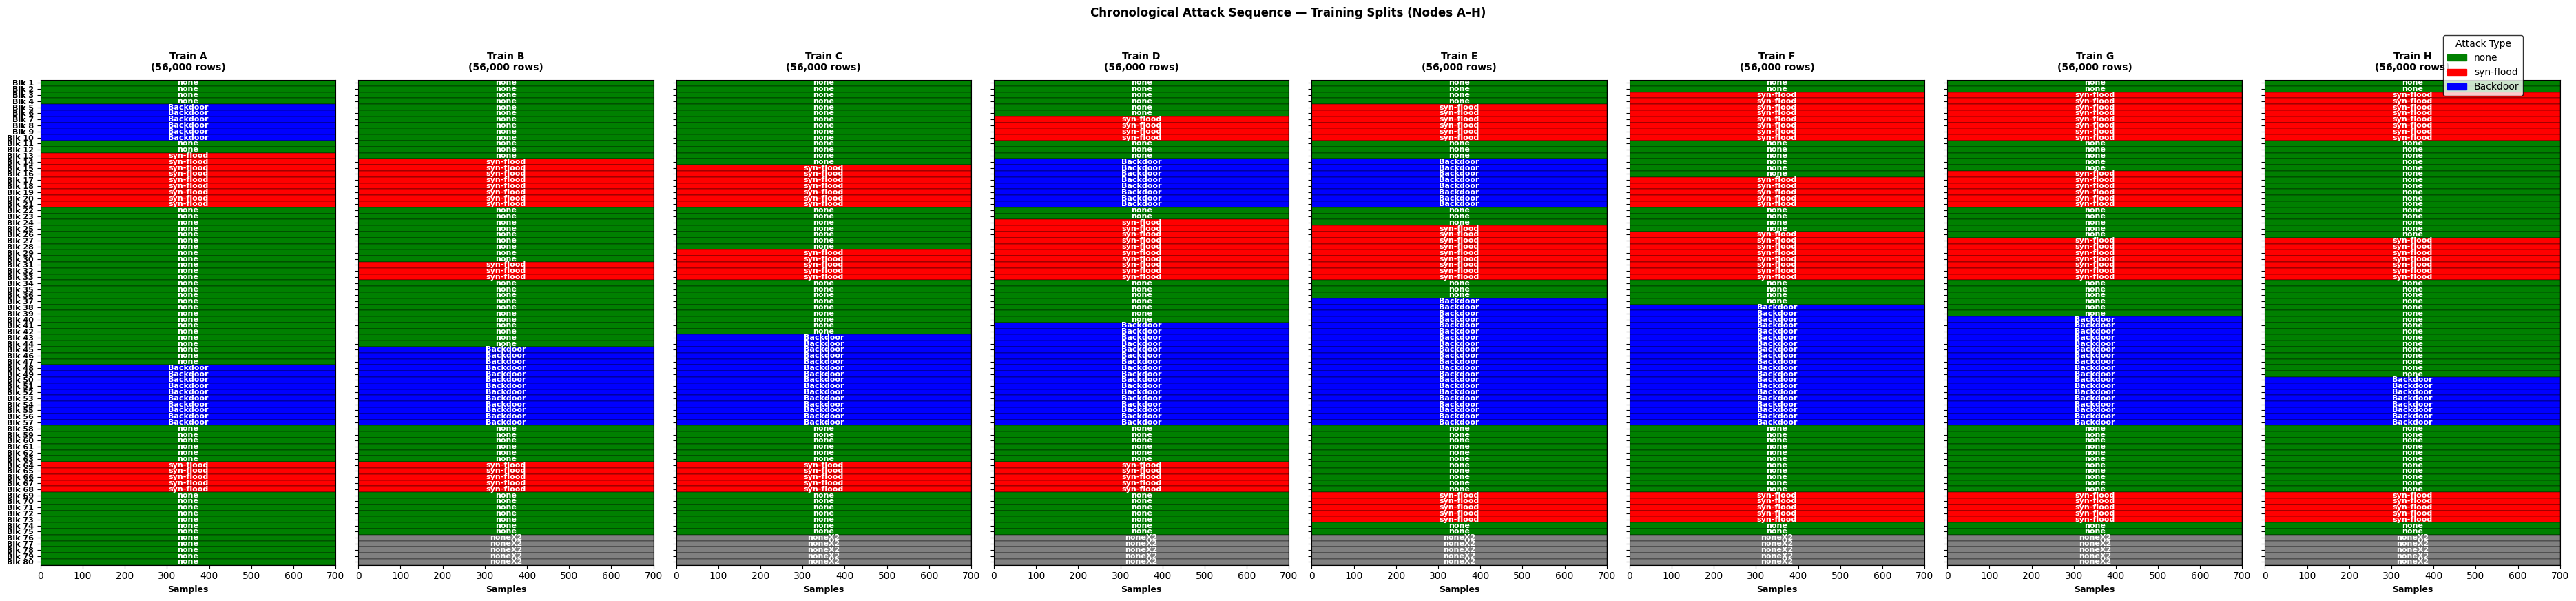

Saved plot to 'plots/test_attack_sequence_nodes_a_h.png'


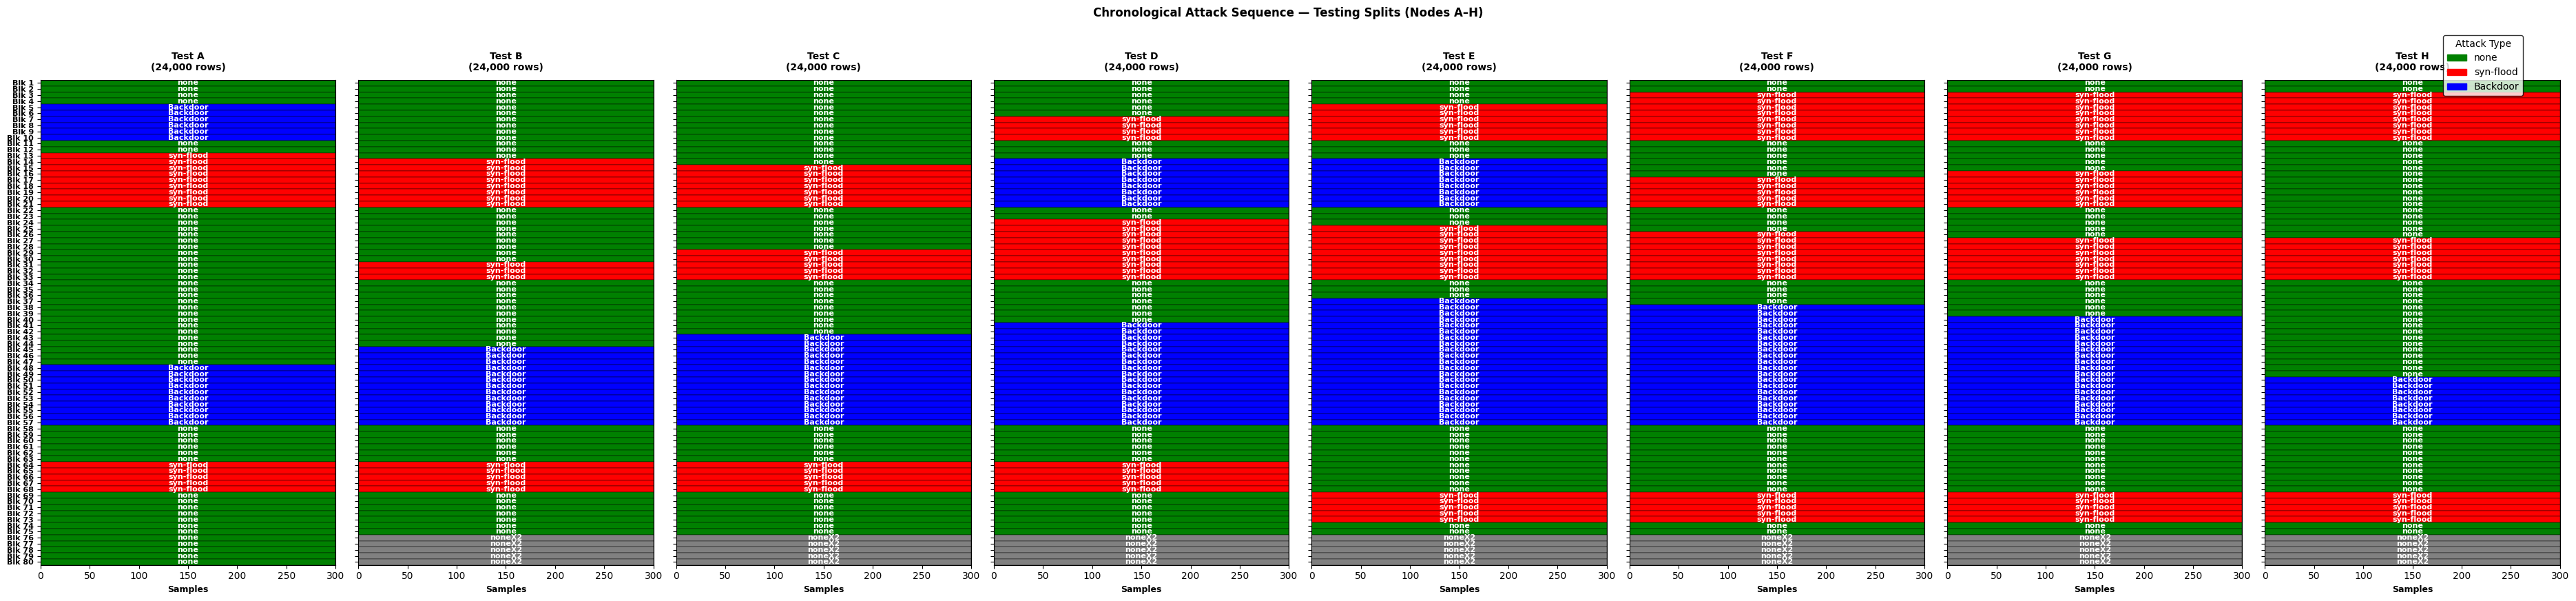

In [6]:
# Cell: Chronological Network Sequence Visualization (Train vs. Test Splits for Nodes B–H)

from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. Configuration & Path Management
# =============================================================================
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Build file mapping dynamically for Training and Testing splits of Nodes A through H
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
NODE_FILES = {}

for node in NODES:
    NODE_FILES[f"Train {node}"] = f"dataset/normalized/Node_{node}_train_normalized.csv"
    NODE_FILES[f"Test {node}"]  = f"dataset/normalized/Node_{node}_test_normalized.csv"

# Split into two separate lists for the two desired subplots
TRAIN_NODES = [f"Train {node}" for node in NODES]
TEST_NODES = [f"Test {node}" for node in NODES]

ATTACK_PALETTE = {
    "none": "green",
    "syn-flood": "red",
    "Backdoor": "blue",
}

# =============================================================================
# 2. Dual-Figure Generation (Train Split vs. Test Split)
# =============================================================================
def plot_sequence_grid(node_list, title_text, output_filename):
    n_nodes = len(node_list)
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=n_nodes, 
        figsize=(4.5 * n_nodes + 1.5, 8.5), 
        sharey=True
    )

    if n_nodes == 1:
        axes = [axes]

    max_blocks = 0

    for ax, node_name in zip(axes, node_list):
        file_path = Path(NODE_FILES[node_name])
        
        if not file_path.exists():
            ax.set_title(f"{node_name}\n(File not found)", fontsize=10, fontweight="bold", color="red")
            continue

        df = pd.read_csv(file_path)
        total_rows = len(df)
        
        # 80 blocks baseline configuration, scaled to split length
        n_blocks_expected = 80
        block_size = total_rows / n_blocks_expected
        block_size = int(block_size) if block_size.is_integer() else max(1, int(block_size))
        
        df["row_index"] = np.arange(total_rows)
        df["block_id"] = df["row_index"] // block_size
        n_blocks = df["block_id"].nunique()
        max_blocks = max(max_blocks, n_blocks)

        for b in range(n_blocks):
            block_data = df[df["block_id"] == b]
            if len(block_data) == 0:
                continue
            attack_type = block_data["Attack"].mode()[0]
            color = ATTACK_PALETTE.get(attack_type, "gray")
            actual_block_rows = len(block_data)

            ax.barh(
                y=b,
                width=actual_block_rows,
                height=1,
                color=color,
                edgecolor="black",
                linewidth=0.3,
                alpha=1.0,
            )
            
            ax.text(
                x=actual_block_rows / 2,
                y=b,
                s=attack_type,
                color="white",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
            )

        ax.set_ylim(n_blocks - 0.5, -0.5)
        ax.set_xlim(0, block_size if block_size > 0 else 1)
        ax.set_xlabel(f"Samples", fontsize=9, fontweight="bold")
        ax.set_title(
            f"{node_name}\n({total_rows:,} rows)", 
            fontsize=10, 
            fontweight="bold", 
            pad=10
        )

    if max_blocks > 0:
        axes[0].set_yticks(range(max_blocks))
        axes[0].set_yticklabels([f"Blk {b+1}" for b in range(max_blocks)], fontsize=8, fontweight="bold")

    legend_handles = [
        mpatches.Patch(color="green", label="none"),
        mpatches.Patch(color="red", label="syn-flood"),
        mpatches.Patch(color="blue", label="Backdoor"),
    ]
    fig.legend(
        handles=legend_handles,
        title="Attack Type",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        facecolor="white",
        edgecolor="black"
    )

    plt.suptitle(title_text, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()

    output_file = OUTPUT_DIR / output_filename
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to '{output_file}'")

    plt.show()
    plt.close(fig)

# Generate Plot 1: Training Splits (Nodes A–H)
plot_sequence_grid(TRAIN_NODES, "Chronological Attack Sequence — Training Splits (Nodes A–H)", "train_attack_sequence_nodes_a_h.png")

# Generate Plot 2: Testing Splits (Nodes A–H)
plot_sequence_grid(TEST_NODES, "Chronological Attack Sequence — Testing Splits (Nodes A–H)", "test_attack_sequence_nodes_a_h.png")